## Transformers y LLMs
- Normalmente las LLMs utilizan bloques de transformers
- Sin embargo, antes utilizaban tanto arquitecturas convolucionales (CNN) como recurrentes (RNN, LSTM).
- Las RNN suelen trabajar mejor cuando el set de datos es pequeño, pero rápidamente los transformers sobrepasan estas redes cuando tenemos cantidades masivas de datos, tanto en tiempo, recursos y precisión.
- Esto indica que las arquitecturas con transformers demandan cantidades gigantes datos (LLMs).


## Entrenamiento general de una LLM

- Pre-entrenamiento
- Fine-tuning

## Tipos de tareas para el pre-entrenamiento

- Predicción de la palabra siguiente
- Predicción de las palabras ocultas en una oración

¿Tipo de aprendizaje?

## Tipos de tareas para las LLM ya pre-entrenadas
- Text completion

Entrada: Qué día

Salida: es hoy.

- Zero-shot learning

Entrada: ¿Cómo se dice "hola" en portugés?

Salida: Olá o oi.

- Few-shot learning

Entrada: Si Gaot => gato, Lzu => luz y Osfá => sofá. Entonces Puetra => ?

Salida: Puerta

- "Emergent behavior"

Son tareas para la que el modelo no fue entrenado en forma directa, sino que es un efecto colateral descubierto después. Esto se aprende debido a la cantidad de datos que se entrega al modelo durante el pre-entrenamiento.
  - Traducir un lenguaje a otro.
  - Generación de código.
  - Creación de historias de ficción.
  - Más...

# Arquitectura a trabajar: Generative Pre-trained Transformer



## Procesamiento de datos
  - Obtención de los *word embedings*
  - Convertir cada palabra a un vector de características
  - Este vector de características es especial, pues es aprendido y generado por un modelo de *deep learning*
  - Pasos
    - Dividir oraciones completas de texto en símbolos del lenguaje (palabras, signos de puntuación, etc.)
    - Tokenización: asignar a cada símbolo un *tokens*
    - Convertir un *token* en un *embedding vector*

- Descargar el conjunto de datos o *corpus*: "The verdict" para ejemplificar el proceso de procesamiento de datos de un *corpus* más grande para entrenar LLMs.

In [ ]:
import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
 "the-verdict.txt")
file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)
with open("the-verdict.txt", "r", encoding="utf-8") as f:
 raw_text = f.read()
print("Total number of character:", len(raw_text))
print(f"{raw_text[:200]}...")


Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a...


La forma más simple de programar un tokenizador es mediante una expresión regular que separe los símbolos. En este caso la expresión regular va a separar símbolos especiales y palabras que siguen inmediatamente un espacio en blanco.

- ¿Cuándo es necesario filtrar los espacios en blanco?

In [ ]:
import re
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))
print(preprocessed[:30])

4690
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


Se ve en la celda anterior que hay 4690 símbolos en donde algunos obviamente están repetidos. Por lo tanto, hay que identificar cada símbolo como un *token* especial.

De esta forma, se genera el vocabulario con respecto al *corpus*, en donde cada *token* único se identifica con un identificador. El vocabulario, idealmente, esta ordenado alfabéticamente.

In [ ]:
words = sorted(set(preprocessed))
vocabulary_size = len(words)
vocabulary = { token: idx for idx, token in enumerate(words) }
print(vocabulary_size)
print([token for idx, token in enumerate(vocabulary.items())])

1130
[('!', 0), ('"', 1), ("'", 2), ('(', 3), (')', 4), (',', 5), ('--', 6), ('.', 7), (':', 8), (';', 9), ('?', 10), ('A', 11), ('Ah', 12), ('Among', 13), ('And', 14), ('Are', 15), ('Arrt', 16), ('As', 17), ('At', 18), ('Be', 19), ('Begin', 20), ('Burlington', 21), ('But', 22), ('By', 23), ('Carlo', 24), ('Chicago', 25), ('Claude', 26), ('Come', 27), ('Croft', 28), ('Destroyed', 29), ('Devonshire', 30), ('Don', 31), ('Dubarry', 32), ('Emperors', 33), ('Florence', 34), ('For', 35), ('Gallery', 36), ('Gideon', 37), ('Gisburn', 38), ('Gisburns', 39), ('Grafton', 40), ('Greek', 41), ('Grindle', 42), ('Grindles', 43), ('HAD', 44), ('Had', 45), ('Hang', 46), ('Has', 47), ('He', 48), ('Her', 49), ('Hermia', 50), ('His', 51), ('How', 52), ('I', 53), ('If', 54), ('In', 55), ('It', 56), ('Jack', 57), ('Jove', 58), ('Just', 59), ('Lord', 60), ('Made', 61), ('Miss', 62), ('Money', 63), ('Monte', 64), ('Moon-dancers', 65), ('Mr', 66), ('Mrs', 67), ('My', 68), ('Never', 69), ('No', 70), ('Now', 71)

Del código anterior vemos que hay 1130 *tokens* o "palabras" en nuestro vocabulario (únicas).
Para poner todos los pasos juntos, se va a crear una clase tokenizadora.

In [ ]:
class SimpleTokenizerV1:
  def __init__(self, vocab):
    self.map_str_to_int = vocab
    self.map_int_to_str = {i:s for s, i in vocab.items()}

  def encode(self, text):
    preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    ids = [self.map_str_to_int[s] for s in preprocessed]
    return ids

  def decode(self, ids):
    text = " ".join([self.map_int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

tokenizer = SimpleTokenizerV1(vocabulary)
text = """"It's the last he painted, you know,"
 Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)
print(tokenizer.decode(ids))

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]
" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


En general, este tokenizador trabaja bien, sin embargo, cualquier palabra que no esté en el vocabulario no va a poder ser codificada/decodificada luego. Si no hacemos algo para manejar *tokens* desconocidos, ante cualquier entrada nueva vamos a tener errores.

### *Tokens* de contexto

- <|unk|>: identifica cualquier token no registrado en el vocabulario, evitando caer en errores al procesar una entrada con palabras nuevas/desconocidas.
- <|endoftext|>: permite delimitar diferentes textos no relacionados entre sí, dentro de un mismo *corpus*. Normalmente todos los documentos (por ejemplo, varios libros) son concatenados para entrenarlo en una sola pasada, sin embargo, se necesita una forma se demarcar el final de un texto e inicio de otro texto (libro, documento, revista, página web, etc.
- [BOS]: Indica el inicio de una oración de entrada/salida.
- [EOS]: Indica el fin de una oración entrada/salida.
- [PAD]: Como las oraciones tienen tamaños variables, y el entrenamiento ocurre en lotes (*batches*), normalmente se toma la oración más grande como el tamaño de vector y todas las demás oraciones cortas se rellenan con *tokens* de *padding*.


In [ ]:
tokens = sorted(list(set(preprocessed)))
tokens.extend(["<|unk|>", "<|endoftext|>"])
vocabulary = { token: idx for idx, token in enumerate(tokens) }
print(len(vocabulary.items()))

class SimpleTokenizerV2:
  def __init__(self, vocab):
    self.map_str_to_int = vocab
    self.map_int_to_str = {i:s for s, i in vocab.items()}

  def encode(self, text):
    preprocessed =  re.split(r'([,.:;?_!"()\']|--|\s)', text)
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    preprocessed = [item if item in self.map_str_to_int else "<|unk|>" for item in preprocessed]
    ids = [self.map_str_to_int[s] for s in preprocessed]
    return ids

  def decode(self, ids):
    text = " ".join([self.map_int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
    return text

tokenizer = SimpleTokenizerV2(vocabulary)
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
# Notar que "Hello" ni "palace" existen en el vocabulario, sin embargo, se pre-procesa sin problemas.
# Concatenar dos "corpus" no relacionados.
text = " <|endoftext|> ".join((text1, text2))
print(text)
print(tokenizer.encode(text))
print(tokenizer.decode(tokenizer.encode(text)))

1132
Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.
[1130, 5, 355, 1126, 628, 975, 10, 1131, 55, 988, 956, 984, 722, 988, 1130, 7]
<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


### Byte-pair encoding (BPE)

Este esquema de tokenización es mucho más sofisticado que utilizar expresiones regulares. Por ello, implementarlo de 0 es una tarea ardua. La biblioteca `tiktoken` se especializa en BPE.

In [ ]:
# https://github.com/openai/tiktoken
!pip install tiktoken

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(ids)
print(tokenizer.decode(ids))

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]
Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


- El codificador BPE utilizado para "gpt2" no tiene el *token* "<|unk|>. Sin embargo, "someunknownPlace" es una palabra que no está en ningún vocabulario, e igual puede codificar la oración.
- Por ejemplo, la palabra "someunkownPlace", internamente, es dividida en múltiples sub-palabras, como
    - Some, unknown, Place
- En el caso anterior era fácil pues todas son separables inmediatamente
- Sin embargo, alguna palabra como "Akwiwr" no tiene mucho sentido, y es posible que el codificador separe incluso hasta carácter por carácter la palabra.

In [ ]:
def get_string(encoding, token_id):
  token_bytes = encoding.decode_single_token_bytes(token_id)
  token_string = token_bytes.decode("utf-8", errors="replace")
  return token_string

encoded_text = tokenizer.encode("Akwirw")
print(encoded_text)
decoded_text = tokenizer.decode(encoded_text)
print(decoded_text)

for token_id in encoded_text:
  print(get_string(tokenizer, token_id), end=" ")

[33901, 86, 343, 86]
Akwirw
Ak w ir w 

### Obteniendo las entradas para la LLM

- Para entrenar cualquier modelo dentro de ML o DL se necesita el par ($x_i$, $y_i$), es decir, la entrada y la etiqueta.
- En este caso, como gpt predice la siguiente palabra, la entrada como tal es la oración y la etiqueta es la palabra que sigue a la última palabra de la oración.

<center>


![](https://drive.google.com/uc?export=view&id=1f_ZctwtEBwbd5aR3BKTCTkEfhlHJiQAR)


</center>


In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()
encoded_text = tokenizer.encode(raw_text)
print(len(encoded_text))

encoded_text_sample = encoded_text[50:] # Eliminamos las primeras 50 palabras (el texto es más interesante pasadas estas palabras)

context_size = 4 # ¿Cuántas palabras vamos a leer a la vez? (palabras a ser incluídas en la entrada)
x = encoded_text_sample[:context_size] # Tomamos desde el inicio al final del tamaño del contexto
y = encoded_text_sample[1:context_size+1] # Iniciamos de la siguiente posición, y terminamos en la siguiente palabra, pasada la última palabra tras el contexto
print(f"x = {x}")
print(f"y = {y}")

print("\n\nImprimiendo solo los IDs")
for i in range(1, context_size+1):
  context = encoded_text_sample[:i]
  desired = encoded_text_sample[i]
  print(context, "---->", desired)

print("Imprimiendo solo la decodificación")
for i in range(1, context_size+1):
  context = encoded_text_sample[:i]
  desired = encoded_text_sample[i]
  print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

5145
x = [290, 4920, 2241, 287]
y = [4920, 2241, 287, 257]


Imprimiendo solo los IDs
[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257
Imprimiendo solo la decodificación
 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


Lo anterior nos da una intuición de cómo vamos a cargar nuestros datos para alimentar nuestra LLM.

Como recordatorio, en PyTorch cada dataset debe tener su dataloader.

- El Dataset indica cómo se obtienen las entradas y sus etiquetas .
- El Dataloader se encarga de obtener cada lote correctamente y configurar otros aspectos relacionados al uso de recursos.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    self.input_ids = [] # X's
    self.target_ids = [] # y's
    token_ids = tokenizer.encode(txt)

    # Generar pares
    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i:i + max_length]
      target_chunk = token_ids[i + 1: i + max_length + 1]

      # Agregar al conjunto de datos convirtiéndolos a tensores
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx] # Obtener un par para entregar al modelo


def create_dataloader_v1(txt, batch_size=4, max_length=256,
  stride=128, shuffle=True, drop_last=True,
  num_workers=0):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
  dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=shuffle,
    drop_last=drop_last,
    num_workers=num_workers
  )
  return dataloader

raw_text = None
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

# max_length = 4, stride = 1
dataloader = create_dataloader_v1(raw_text,
  batch_size=1, max_length=4, stride=1,
  shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print("max_length = 4, stride = 1")
print(first_batch)
# retorna [x, y]
print(first_batch[0].shape, first_batch[1].shape, "\n")

# max_length = 2, stride = 2
dataloader = create_dataloader_v1(raw_text,
  batch_size=1, max_length=2, stride=2,
  shuffle=False
)

print("max_length = 2, stride = 2")
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)
print(first_batch[0].shape, first_batch[1].shape, "\n")

# max_length = 8, stride = 2
dataloader = create_dataloader_v1(raw_text,
  batch_size=1, max_length=8, stride=2,
  shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print("max_length = 8, stride = 2")
print(first_batch)
print(first_batch[0].shape, first_batch[1].shape, "\n")


max_length = 4, stride = 1
[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
torch.Size([1, 4]) torch.Size([1, 4]) 

max_length = 2, stride = 2
[tensor([[ 40, 367]]), tensor([[ 367, 2885]])]
torch.Size([1, 2]) torch.Size([1, 2]) 

max_length = 8, stride = 2
[tensor([[  40,  367, 2885, 1464, 1807, 3619,  402,  271]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899]])]
torch.Size([1, 8]) torch.Size([1, 8]) 




<center>

![](https://drive.google.com/uc?export=view&id=1fcNBMhrmEPTYdPScgt33rq6fKsOGDR-Q)


</center>


### Creación de los *token embedding vectors*


<center>


![](https://drive.google.com/uc?export=view&id=1fcgzt96mRdQQWN90i0994xNy-Ia8gzr3)


</center>

La generación de embeddings es posible mediante el uso de una capa de "embedding" directamente desde PyTorch.

In [ ]:
example_ids = torch.tensor([2, 3, 5, 1])
vocab_size = 6 # Ej., vocab = [1, 2, 3, 4, 5, 6]
output_dim = 3

torch.manual_seed(42)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight) # Ver cómo se inicializaron los pesos aleatorios

Parameter containing:
tensor([[ 1.9269,  1.4873, -0.4974],
        [ 0.4396, -0.7581,  1.0783],
        [ 0.8008,  1.6806,  0.3559],
        [-0.6866,  0.6105,  1.3347],
        [-0.2316,  0.0418, -0.2516],
        [ 0.8599, -0.3097, -0.3957]], requires_grad=True)


Es posible notar que la capa de *embeddings* contiene seis filas y tres columnas, es decir, hay una fila para cada posible *token* del vocabulario y una columna para cada dimensión del espacio de *embeddings*.
Para obtener el *embedding* para un token:

In [ ]:
picked_token_id = example_ids[0] # 2
print(embedding_layer(torch.tensor([picked_token_id])))

tensor([[0.8008, 1.6806, 0.3559]], grad_fn=<EmbeddingBackward0>)


Este *embedding* tiene algo especial: ya se puede identificar en la matriz de parámetros de la capa (fila con índice 2).
- Esto nos indica que una capa de *embeddings* es simplemente una "tabla"/diccionario que mapea un *token_id* a un vector de dimensión 3 (*token_id* => *embedding*).
- Claramente la ventaja de que sea una capa de red neuronal es que los pesos de la matriz de la capa oculta se van a ajustar durante el entrenamiento.

In [ ]:
# Normalmente vamos a pasar toda una oración por la capa y no sólo un token
print(embedding_layer(example_ids)) # shape == (4 (entrada), 3 (dimensión del embedding))


tensor([[ 0.8008,  1.6806,  0.3559],
        [-0.6866,  0.6105,  1.3347],
        [ 0.8599, -0.3097, -0.3957],
        [ 0.4396, -0.7581,  1.0783]], grad_fn=<EmbeddingBackward0>)


Hasta ahora parece todo funcionar bien para entrenar una LLM mediante la arquitectura *transformer*. Sin embargo, no tenemos información posicional o de orden en una oración de entrada.
- Esto se puede claramente, ya que para cada *token_id* pasado por la capa de *embeddings* siempre se retornará la misma representación vectorial, independientemente de si el token original está al inicio, al medio o al final de la secuencia.
- Por ello hay que encontrar una forma de codificar la posición y dar una noción de orden a la oración

#### *Positional embeddings*

- Absoluto:
    - Se relacionan con la posición específica de un token en una secuencia.
    - Para cada *token* en cierta posición, se le suma un nuevo *embedding* determinado por esta posición.
    - Ahora un *token* en la posición 0 y el mismo *token* en la posición 4 van a tener distintas representaciones vectoriales finales debido a que se suma un *embedding* posicional distinto.
- Relativo:
    - Se determina un *embedding* tomando en cuenta la posición relativa o la distancia entre *tokens*.

- Ambas representaciones pueden ser optimizadas durante el entrenamiento (agregar capas con parámetros aprendibles para obtenerlas).

In [ ]:
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
max_length = 4
dataloader = create_dataloader_v1(
 raw_text, batch_size=8,
 max_length=max_length, stride=max_length, # Si stride == max_length => no hay overlapping entre oraciones a través de los lotes
 shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Token IDs:\n", inputs)
print("Forma de la entrada para una forward-pass sin embeddings:\n", inputs.shape)

# Obtener embeddings para cada palabra dentro de una oración (8 en total)
token_embeddings = token_embedding_layer(inputs)
print("Forma de la entrada para una forward-pass obteniendo embeddings:\n", token_embeddings.shape)

# Crear una capa de absolute positional embeddings
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length)) # Se entrega tensor [0, ..., n-1] (cantidad de tokens en una secuencia/oración)
print("Forma de los embeddings posicionales absolutos:\n", pos_embeddings.shape)

# Como vimos, solo necesitamos sumar ambos embeddings
# Gracias al broadcast es posible sumar dos tensores con diferentes atributos para shape (8, 4, 256) y (4, 256)
input_embeddings = token_embeddings + pos_embeddings
print("Forma final (suma) de embeddings posicionales absolutos:\n", input_embeddings.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Forma de la entrada para una forward-pass sin embeddings:
 torch.Size([8, 4])
Forma de la entrada para una forward-pass obteniendo embeddings:
 torch.Size([8, 4, 256])
Forma de los embeddings posicionales absolutos:
 torch.Size([4, 256])
Forma final (suma) de embeddings posicionales absolutos:
 torch.Size([8, 4, 256])


- Pre-procesamiento de la información para una LLM.
- El texto se convierte en tokens, para formar un vocabulario con tokens únicos, asignando a cada uno un ID.
- Se obtiene una repesentación en un espacio dimensional mayor para cada token, y para cada oración se obtiene el vector correspondiente.
- Para añadir información contextual, se añaden *positional embeddings*.
- Existen tokens especiales.
- Hay que tener en cuenta entradas que no se encuentran en el vocabulario.
- El tokenizador utiliza la estrategia Byte-Pair Encoder (BPE)
- Para los *positional embeddings* se utiliza una estrategia absoluta.


## Mecanismos de atención

Algunas preguntas que se deberían poder responder son:
- ¿Por qué usar mecanismos de atención?
- Atención básica vs. parametrizada
- *Self-attention*
- Atención causal mediante máscaras de atención
- Atención multi-cabezal

1. RNNs

Las RNN son redes utilizadas para procesar secuencias, mediante una arquitectura codificador-decodificador.

El codificador genera un estado comprimido con la información de toda la secuencia y el decodificador intenta predecir a través de este estado resultante una predicción para cada posición en la secuencia.

Una limitación es que el decodificador en una RNN solo utiliza el último estado producido por la RNN, y no puede acceder a estados anteriores o futuros, lo que hace perder información contextual de largo alcance (más lejana).

Con la introducción de la atención aditiva o *Bahdanau attention* (2014) el decodificador tiene acceso a todas las posiciones de la secuencia de entrada, prestando más o menos "atención" a ciertas palabras, si la secuencia es una oración.

Con la introducción de la arquitectura de *transformers* (2017) se demuestra que no es necesario utilizar una RNN y únicamente el mecanismo de atención es lo importante (pilar fundamental), introduciendo la *self-attention*.

Es llamada *auto* atención debido a que se computa la atención entre los mismos *embeddings* de entrada (entrada $\times$ entrada), a diferencia de la utilizada en RNN en donde desde el estado de salida del codificador se obtenía la atención sobre la entrada.

### Componentes de la *self-attention*
Considerando que la secuencia es de largo $T$:

- Token *embeddings* ($x^{(j)}$)
  - Recordando que los *embeddings* finales son resultado de la suma de los *embeddings* originales más los *positional embeddings*
- Coeficientes de atención ($\alpha_{ij}$).
  - Indican la atención que se le presta a cada embedding cuando estamos en una posición de la secuencia.

  Como hablamos de *self-attention*, cada coeficiente se obtiene tomando en cuenta TODOS los demás *embeddings* con respecto a un *embedding* específico (una posición de la secuencia de entrada).

- Vector de contexto ($z^{(i)}$)
  - Es el resultado de ponderar cada coeficiente de atención con su respectivo *embedding*, entregando un vector con información contextual de toda la secuencia para una posición específica.
  - Es posible notar que los coeficientes de atención conectan un token $i$ de la secuencia a todos los demás tokens $j$ mediante un peso $\alpha_{ij}$ codificando toda esta relación en el vector de contexto para el token $i$ como $z^{(i)}$.
  - En conclusión, para cada token $x$ en la posición $i$ de la secuencia de entrada vamos a generar un vector contextual. En otras palabras, es posible decir que se genera otro *embedding* mucho más enriquecido.


Primero, vamos a ver una versión simplificada de la *self-attention*.

In [ ]:
import torch

# La oración se tokeniza y codifica, convirtiendo la oración en tokens y mapeando cada token a un token_id.
# Finalmente se obtiene un embedding de dimensión = 3 en este caso, para cada embedding.
# Se asume que ya se suman los embeddings posicionales.

inputs = torch.tensor([
 [0.43, 0.15, 0.89],  # Your    (x_1)
 [0.55, 0.87, 0.66],  # journey (x_2)
 [0.57, 0.85, 0.64],  # starts  (x_3)
 [0.22, 0.58, 0.33],  # with    (x_4)
 [0.77, 0.25, 0.10],  # one     (x_5)
 [0.05, 0.80, 0.55],  # step    (x_6)
])

print("Secuencia de entrada: ", inputs.shape)

# Vamos a obtener los puntajes de atención (attention scores)
# Estos son un paso intermedio en el cálculo de los coeficientes de atención como tal

# A la posición actual (un token x_i) se le va a llamar "query"
# Esto, ya que "consulta" el puntaje de atención que debería tener con cada otro
# token de entrada.
# El valor intermedio puede simplemente ser calculado mediante la similaridad coseno,
# para dos vectores, simplemente se debe aplicar el producto punto.

i = 1 # Simulamos estar en la posición x_i = x_2
query_input = inputs[i] # x_2_query
attn_scores_i = torch.empty(inputs.shape[0]) # inicializar vector para guardar resultados

# Iteramos sobre la entrada para ir consultando el puntaje de atención entre x_2 y todos los demás inputs x_j
for j, x_j in enumerate(inputs):
  attn_scores_i[j] = torch.dot(query_input, x_j) # El producto punto entrega un puntaje resultado de la "consulta"

print("Attention scores: ", attn_scores_i)

# Finalmente, con los puntajes de atención es posible calcular las ponderaciones
# mediante los coeficientes de atención (\alpha), normalizados para que sumen 1.
# Para esta normalización fácilmente se puede hacer dividiendo por la suma total,
# o el máximo:

attn_weights_i_tmp = attn_scores_i / attn_scores_i.sum()
print("Attention weights (simple): ", attn_weights_i_tmp)
print("Suma: ", attn_weights_i_tmp.sum())

# O utilizar SoftMax para acentuar valores grandes y minimizar valores pequeños:
# Por otro lado, SoftMax siempre entrega valores positivos (> 0)
# Esto genera una distribución de probabilidad sobre los puntajes de atención.

# Esta fórmula es simple - es mejor utilizar SoftMax de PyTorch.
attn_weights_i = torch.exp(attn_scores_i) / torch.exp(attn_scores_i).sum()
print("Attention weights (SoftMax): ", attn_weights_i)
print("Suma: ", attn_weights_i.sum())

# Obtener los *embeddings* enriquecidos, o bien, los vectores con contexto para x_2 (i=2).
print("\nCálculo de context vector: ")
context_vec_i = torch.zeros(query_input.shape)
for j, x_j in enumerate(inputs):
  print(f"{attn_weights_i[j]} * {x_j} = {attn_weights_i[j]*x_j}")
  context_vec_i += attn_weights_i[j]*x_j
print("Sumando cada vector posición a posición: ")
print("Context vector: ", context_vec_i)

Secuencia de entrada:  torch.Size([6, 3])
Attention scores:  tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Attention weights (simple):  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Suma:  tensor(1.0000)
Attention weights (SoftMax):  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Suma:  tensor(1.)

Cálculo de context vector: 
0.13854758441448212 * tensor([0.4300, 0.1500, 0.8900]) = tensor([0.0596, 0.0208, 0.1233])
0.2378913313150406 * tensor([0.5500, 0.8700, 0.6600]) = tensor([0.1308, 0.2070, 0.1570])
0.23327405750751495 * tensor([0.5700, 0.8500, 0.6400]) = tensor([0.1330, 0.1983, 0.1493])
0.12399159371852875 * tensor([0.2200, 0.5800, 0.3300]) = tensor([0.0273, 0.0719, 0.0409])
0.10818187892436981 * tensor([0.7700, 0.2500, 0.1000]) = tensor([0.0833, 0.0270, 0.0108])
0.15811361372470856 * tensor([0.0500, 0.8000, 0.5500]) = tensor([0.0079, 0.1265, 0.0870])
Sumando cada vector posición a posición: 
Context vector:  tensor([0.4419, 0.6515, 0.5683])


En la celda anterior vemos que:
- Tomamos un vector de entrada $x_2$. Lo llamamos "query" porque vamos a consultar la importancia entre este vector y todos los demás *embeddings* de la entrada.
- Se obtienen los puntajes de atención para $x_2$: Se calcula el producto punto entre el vector $x_{2_{\text{query}}}$ con todas las demás entradas $x_j$ ($j=1\dots T$).
- Se normaliza de alguna forma el vector de *attention scores* para generar los coeficientes de atención finales.
- Se multiplica cada coeficiente de atención $j$ por el *embedding* en la posición $j$. Finalmente, se suman los vectores y se obtiene este nuevo *embedding* enriquecido.

Hasta ahora calculamos sólo la atención para un solo token de entrada. Sin embargo, el proceso fácilmente se puede vectorizar y hacer en una sola multiplicación matricial.

In [ ]:
# Una forma "naive" de hacerlo es usando for-loops.
attn_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attn_scores[i, j] = torch.dot(x_i, x_j)
print(attn_scores)

# Sin embargo, cuando se multiplican tensores, el operador especial "@" permite
# realizar una multiplicación matricial optimizada.
attn_scores = inputs @ inputs.T # Se transpone la matriz para hacer calzar las dimensiones
print(attn_scores)

# Cualquiera sea el método que utilizamos, debemos obtener los
# coeficientes, pues antes solo calculamos los puntajes de atención.
attn_weights = torch.softmax(attn_scores, dim=-1)
print("Coeficientes finales: \n", attn_weights)

# Finalmente obtenemos todos los context vectors
context_vecs = attn_weights @ inputs
print("Context vectors (enriched embeddings): \n", context_vecs)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])
Coeficientes finales: 
 tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.187

<center>


![](https://drive.google.com/uc?export=view&id=1fdDx-talR2csC6Ge5yK1xPvN9R3ORz0p)


</center>

Lo anterior demuestra el uso de *self-attention* en forma manual y simplificada, pues no hay forma de aprender estos *embeddings* contextuales resultantes del mecanismo atencional durante el entrenamiento.

### *Self-attention* parametrizado

Este mecanismo de atención lleva por nombre *scaled dot-product attention*, y utiliza una capa con pesos ajustables (cada una con sus matrices de parámetros).

A continuación se van a introducir las matrices de pesos $W_q$, $W_k$ y $W_v$, que actúan como una sola capa lineal en una red neuronal.

Cada token (una palabra $i$ o $x_i$ en la secuencia de entrada) va a ser proyectado tres veces mediante las tres matrices anteriores, generando la representación del token según:
- Un vector "query": $q_i = W_q x_i$.
- Un vector "key": $k_i = W_k x_i$.
- Un vector "value": $v_i = W_v x_i$.

De álgebra lineal sabemos que la operación entre una matriz y un vector, geométricamente, transforma o proyecta el vector o *token embedding* $x_i$ en el espacio contenido en las matrices $W$.

Es posible notar que el espacio transformado entregar diferentes dimensiones ($d$) para cada vector *query*, *key* y *value* ($d_k$, $d_q$ y $d_v$ pueden ser distintos).



In [ ]:
x_2 = inputs[2 - 1] # Tomar posición de la secuencia i = 2
d_in = inputs.shape[1] # Dimensión de los embeddings de entrada, en este caso es 3.
d_out = 2 # Dimensión de los embeddings de salida tras proyectarlos tres veces
          # (en este caso específico d_k = d_v = d_q = 2)

# Simulamos el inicio del entrenamiento generando 3 matrices W_q, W_k y W_v
# con pesos inicializados aleatoriamente.

torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

# Acá notamos que se realiza la operación x * W en vez de W * x
# Dado que los vectores son vectores "fila" (1, T)
# En álgebra lineal los vectores son representados como columnas (T, 1)
# Si se quiere seguir la notación sería query_2 = W_query @ x_w.T, es decir, convirtiendo un vector fila a columna
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

# Mostrar las 3 nuevas representaciones de la entrada para el token 2 (i=2)
print(query_2) # Query específica

print(key_2)
print(value_2)

# Necesitamos todas las demás representaciones de key y values para los otros tokens
# debido a que vamos a sacar los puntajes de atención despues
keys = inputs @ W_key
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)



tensor([0.4306, 1.4551])
tensor([0.4433, 1.1419])
tensor([0.3951, 1.0037])
keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


- Ahora que ya tenemos 3 representaciones para nuestros *token embeddings* necesitamos calcular los puntajes de atención. En este caso, los puntajes de atención se obtiene, en el producto punto input a input, con las representaciones de los inputs en el espacio de las queries y keys.

In [ ]:
# Calcular solo para token 2 y él mismo (2, 2)
keys_2 = keys[2 - 1]
attn_score_22 = query_2.dot(keys_2) # puntaje de atención sobre sí mismo
print(attn_score_22)

# Calcular para token 2 y todos los tokens a la vez mediante la multiplicatión matricial
# En este caso, la representación de query para el token 2 y la representación de keys para los demás tokens
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

# Calculamos los coeficientes de atención
# Como utilizamos softmax los puntajes pasan a ser probabilidades
# Por esto se llama "scaled" self-attention: se multiplican las
# probabilidades, por un factor de (1/sqrt(d_k))
d_k = keys.shape[-1] # d_k = 2
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print("Coeficientes de atención normalizados y escalados: ", attn_weights_2)

# Por último se calcula el context vector para el token 2
# En vez de utilizar otra vez las entradas originales (*token embeddings*)
# Se utiliza la representación en el espacio de los "values" (W_v)
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor(1.8524)
tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])
Coeficientes de atención normalizados y escalados:  tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])
tensor([0.3061, 0.8210])


Ya calculamos la *scaled dot product self-attention* minimalmente, obteniendo el *context vector* para el token i=2 (en la posición de la oración de entrada 2).

Para consolidar todo lo construido, nuevamente se va a construir una clase que encapsule el comportamiento del mecanismo de atención.

In [ ]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
  def __init__(self, d_in, d_out):
    """
    d_in: dimensión de los embeddings de entrada
    d_out: dimensión de los embeddings de salida tras proyectarlos con las matrices W_q, W_k y W_v
    """

    super().__init__()

    # nn.Parameter
    # Este módulo es igual a nn.Linear (capa densa) pero sin bias
    # Es decir, es idéntico a una transformación lineal u = Wx (transformar x en u mediante W)
    self.W_query = nn.Parameter(torch.rand(d_in, d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):

    # Proyectar tokens de entrada
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value

    # Calcular puntajes de atención
    attn_scores = queries @ keys.T

    # Calcular coeficientes de atención
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )

    # Calcular context vectors finales
    context_vec = attn_weights @ values
    return context_vec

torch.manual_seed(123)
att_module = SelfAttention_v1(3, 2) # Tamaño original de embeddings = 3, d_k = d_v = d_q = 2
print(att_module(inputs)) # Calcular pasada hacia adelante (forward-pass)

# Una versión utilizando la capa densa nn.Linear sin bias se deja comentada:
# Una ventaja es que nn.Linear inicializa mediante una estrategia adecuada
# los pesos y no usando "torch.rand"
class SelfAttention_v2(nn.Module):
  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):

    # Simplemente pasamos los inputs a la capa densa, y esta se encargará de
    # realizar la multiplicación matricial

    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


### *Causal/masked attention*

Escenario: Durante la fase de entrenamiento, al tener un par (X = oración, y = siguiente palabra a predecir), con el mecanismo de atención descrito, el modelo puede "hacer trampa" y prestar atención a palabras que están más adelante que el token $i$ actual que se procesa.

Durante "inferencia" o evaluación, el modelo no puede prestar atención a palabras "más adelante" pues las palabras se generan uno a uno, por lo que este es un comportamiento que se debe corregir.

Para ello, a los *tokens* de entrada se les aplica una máscara que esconde los tokens más allá de la posición $i$ ($i+1 \dots T$) que se procesa obligando al modelo a tomar atención solo a los $i \dots 0$ *tokens* anteriores.

<center>


![](https://drive.google.com/uc?export=view&id=1fjTiasp6811BdVe7hFfw9qPA91XelMt_)


</center>

In [ ]:
torch.manual_seed(123)
att_module = SelfAttention_v2(3, 2) # Tamaño original de embeddings = 3, d_k = d_v = d_q = 2

queries = att_module.W_query(inputs)
keys = att_module.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

# En este punto se calcularían los context vectors
context_length = attn_scores.shape[0]
mask_ones = torch.tril(torch.ones(context_length, context_length))
print(mask_ones)

# Ocultamos los valores arriba de la diagonal
masked_coefs = attn_weights * mask_ones # "*" ES PUNTO A PUNTO.
print(masked_coefs)

# Como ahora las filas ya no suman 1, se re-normalizan.
row_sums = masked_coefs.sum(dim=-1, keepdim=True)
masked_coefs_norm = masked_coefs / row_sums
print(masked_coefs_norm)

tensor([[0.1717, 0.1762, 0.1761, 0.1555, 0.1627, 0.1579],
        [0.1636, 0.1749, 0.1746, 0.1612, 0.1605, 0.1652],
        [0.1637, 0.1749, 0.1746, 0.1611, 0.1606, 0.1651],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.1632, 0.1674],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.1639],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])
tensor([[0.1717, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1636, 0.1749, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1637, 0.1749, 0.1746, 0.0000, 0.0000, 0.0000],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.0000, 0.0000],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<MulBackward0>)
tensor([[1.0000, 0.0000, 0.0000

Sin embargo, utilizamos la propiedad de la función SoftMax. Los valores negativos muy pequeños ($\to-\infty$) se aproximan a 0 y los positivos muy altos a 1.

Por lo tanto, la máscara en vez de ser 0 inmediatamente, primero va a ser $-\infty$ en las posiciones sobre la diagonal principal.

In [ ]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked_scores = attn_scores.masked_fill(mask.bool(), -torch.inf)
print("Puntajes con posiciones ocultas:\n", masked_scores)

# Ahora es posible normalizar en un solo paso, ahorrando re-normalizar y luego
# pasar por SoftMax
attn_weights = torch.softmax(masked_scores / keys.shape[-1]**0.5, dim=1)
print("Coef. con pos. ocultas y normalizados:\n", attn_weights)

Puntajes con posiciones ocultas:
 tensor([[0.3111,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.1655, 0.2602,   -inf,   -inf,   -inf,   -inf],
        [0.1667, 0.2602, 0.2577,   -inf,   -inf,   -inf],
        [0.0510, 0.1080, 0.1064, 0.0643,   -inf,   -inf],
        [0.1415, 0.1875, 0.1863, 0.0987, 0.1121,   -inf],
        [0.0476, 0.1192, 0.1171, 0.0731, 0.0477, 0.0966]],
       grad_fn=<MaskedFillBackward0>)
Coef. con pos. ocultas y normalizados:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4833, 0.5167, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3190, 0.3408, 0.3402, 0.0000, 0.0000, 0.0000],
        [0.2445, 0.2545, 0.2542, 0.2468, 0.0000, 0.0000],
        [0.1994, 0.2060, 0.2058, 0.1935, 0.1953, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)


Lo último que se puede aplicar es una capa de *Dropout* para prevenir el *overfitting*. Es decir, además de prevenir que el modelo atienda a otras palabras en las posiciones $i+1$, se va a prevenir aleatoriamente que ponga atención en otras palabras, eligiendo una probabilidad $p$, normalmente entre $[0.1, 0.5]$. Es decir, entre 10% y 50% de las palabras se van a omitir y no se les prestará atención.

In [ ]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

# Específicamente...
print(dropout(attn_weights))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])
tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.6816, 0.6804, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.5085, 0.4936, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3906, 0.0000],
        [0.3249, 0.3418, 0.0000, 0.3308, 0.3249, 0.3363]],
       grad_fn=<MulBackward0>)


Otra vez, lo único que falta es consolidar todo en una clase específica que herede de un módulo de PyTorch.
Los principales cambios que haremos son:
- La implementación de *masked attention* con *dropout*.
- Poder aceptar batches de oraciones en vez de 1 sola secuencia.

In [ ]:
class MaskedAttention(nn.Module):
  """
   d_in: tamaño de embeddings originales.
   d_out: tamaño de embeddings proyectados mediante W_v, W_k y W_q.
   context_length: Tamaño de la oración/secuencia a considerar.
   dropout: Porcentaje de tokens a omitir (en realidad, es una probabilidad)
   qkv_bias: Indica si las matrices de pesos deberían llevar o no un bias
  """
  def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
    super().__init__()
    self.d_out = d_out
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout) # Añadir capa de dropout

    # Se registra la máscara en un buffer de forma que durante el entrenamiento
    # no tengamos que preocuparnos de mover estos tensores a la CPU o GPU manualmente
    self.register_buffer(
      'mask',
      torch.triu(torch.ones(context_length, context_length),
        diagonal=1)
    )

  def forward(self, x):
    # obtener tamaño de batch utilizado; la cantidad de tokens en la secuencia; y el tamaño de los embeddings
    b, num_tokens, d_in = x.shape

    # Proyectar tokens 3 veces
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    # Obtener puntajes
    attn_scores = queries @ keys.transpose(1, 2)

    # Crear máscara para ocultar tokens en posición i+1..T usando el truco de SoftMax
    attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)

    # Obtener coeficientes de atención escalados por (1/sqrt(d_k))
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

    # Añadir la capa de dropout durante entrenamiento para prevenir overfitting
    attn_weights = self.dropout(attn_weights)
    context_vec = attn_weights @ values

    # Retonar embeddings contextuales
    return context_vec

# Generamos un lote "artificial", duplicando el input
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)  # Ahora tenemos dos oraciones en un lote


torch.manual_seed(123)
context_length = batch.shape[1]
masked_att_mechanism = MaskedAttention(d_in, d_out, context_length, 0.0)
context_vecs = masked_att_mechanism(batch)
print("context_vecs.shape:", context_vecs.shape)

torch.Size([2, 6, 3])
context_vecs.shape: torch.Size([2, 6, 2])


### *Multi-head attention*

La atención multicabezal extiende aún más la estrategia fundamental de la arquitectura de los *transformers*:
- Expresar los *token embeddings* de la entrada en diferentes espacios de representación (query/key & values), que son aprendidos durante el entrenamiento.
- Para extender esta idea, es posible, en forma paralela, replicar el mecanismo de atención $n$ veces y resumir todos los al final.
- Este número $n$ indica la cantidad de "cabezales" de atención que va a tener nuestro modelo.
- Cada *token embedding* va a ser representado por $3n$ vectores distintos repartidos en query, keys y values.
- La hipótesis es que se va a poder obtener información de distintos espacios vectoriales y recuperar lo más importante al final de la red.

Para implementar la atención multicabezal pueden haber dos estrategias:
1. Simple: Apilar/concatenar cada mecanismo de atención uno sobre otro (no permite una completa paralelización). Al final, vamos a tener $n$ *context vectors* por cada *token embedding* que deben ser combinados. Si elegimos simplemente concatenarlos, entonces el *embedding* final va a tener d_k * n componentes (ej., 2 * 2 = 4 componentes, con una dimensión proyectada de 2 y 2 cabezales de atención)
2. En la segunda implementación, más complicada, todo se trabaja al mismo tiempo.



In [ ]:
class MultiHeadAttentionWrapper(nn.Module):

  # Simplemente pasamos los mismos parámetros del módulo MaskedAttention
  # incluyendo el número de "cabezales" de atención (num_heads)
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    self.heads = nn.ModuleList([
      MaskedAttention(d_in, d_out, context_length, dropout, qkv_bias)
      for _ in range(num_heads)
    ])

  def forward(self, x):
    return torch.cat([
        head(x) for head in self.heads # Llamos cada "forward" individualmente
      ],
      dim=-1) # Concatenar a lo largo de la última dimensión

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    # Proyección de la salida
    self.out_proj = nn.Linear(d_out, d_out)

    # Capa de dropout
    self.dropout = nn.Dropout(dropout)

    # Manejar paso de máscara a device elegido automáticamente
    self.register_buffer(
      "mask",
      torch.triu(torch.ones(context_length, context_length),
      diagonal=1)
    )

  def forward(self, x):
    b, num_tokens, d_in = x.shape

    # Realizar proyección
    # Tienen dimensiones (batch_size, num_tokens, dimensión proyectada)
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    # Modificamos las matrices añadiendo una nueva dimensión, el número de "attention heads"
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    # Cambiar dimensiones (swap):
    # (batch, num_tokens, num_heads, head_dim) <-> (batch, num_heads, num_tokens, head_dim)
    # De esta forma dividimos internamente una gran matriz Q en Q_1, ..., Q_n donde n = numero de cabezales
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    # Obtener producto punto para cada cabezal
    attn_scores = queries @ keys.transpose(2, 3)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_scores.masked_fill_(mask_bool, -torch.inf)

    # Obtener coeficientes y aplicarles dropout
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1, 2)

    # Un "flatten" sofisticado de todos los context vectors para cada token
    context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

    # Mejor agregación: proyectar a dimensión requerida
    # Se pasa el vector "aplanado" por una capa que proyecta y elige
    # las mejores características para la salida
    context_vec = self.out_proj(context_vec)
    return context_vec

torch.manual_seed(123)
batch = torch.stack((inputs, inputs), dim=0) # otra vez crear un lote "falso" duplicando una sola secuencia
batch_size, context_length, d_in = batch.shape

d_out = 2 # dimensión de tokens proyectados
multihead_attn = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = multihead_attn(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


El código anterior es ejemplificado en el libro "Build a Large Language Model (From Scratch)", y cubre lo principal para codificar mecanismos de atención.
Si alguno desea implementar todo realmente desde cero, debería partir del capítulo 4 del libro (a partir de la página 92).

Paper del modelo GPT.
https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf

Build a Large Language Model (From Scratch). Sebastian Raschka. (2023). Capítulo 1, 2 y 3.


## Utilizando los pesos públicos de GPT-2



In [ ]:
# Instalar las biblioteca de HugginFace (repositorio de modelos open-source):
# !pip install transformers

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Input prompt: Hello! We're here celebrating new year after Christmas came

Top-5 predictions for next token:
' to': 0.7243
' and': 0.2223
' a': 0.0349
' along': 0.0109
' early': 0.0054


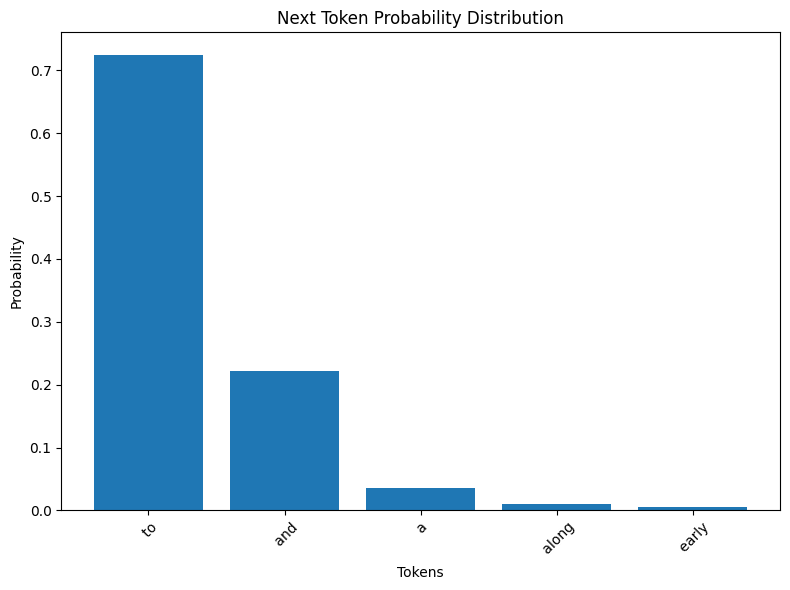


Top-5 predictions for next token:
' an': 0.5105
' a': 0.4628
' us': 0.0180
' our': 0.0049
' the': 0.0038


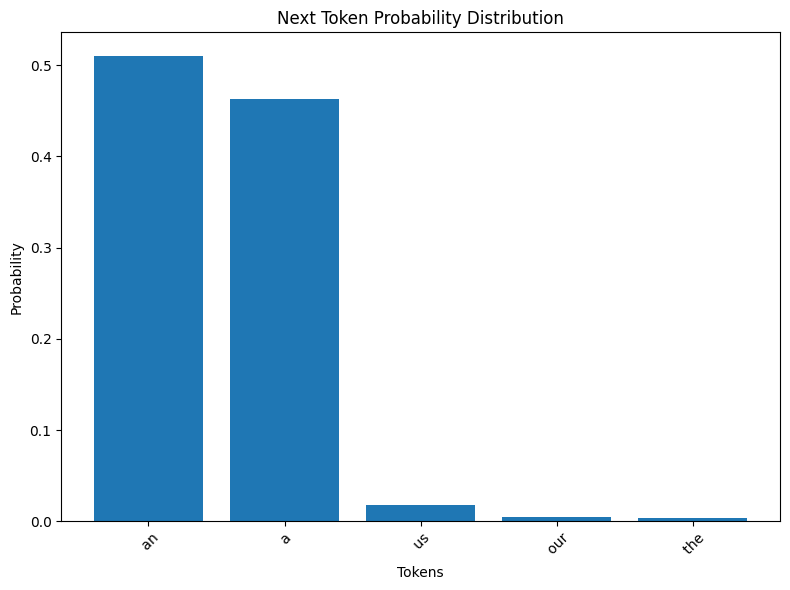


Top-5 predictions for next token:
' end': 1.0000
' abrupt': 0.0000
' unexpected': 0.0000
' early': 0.0000
' ending': 0.0000


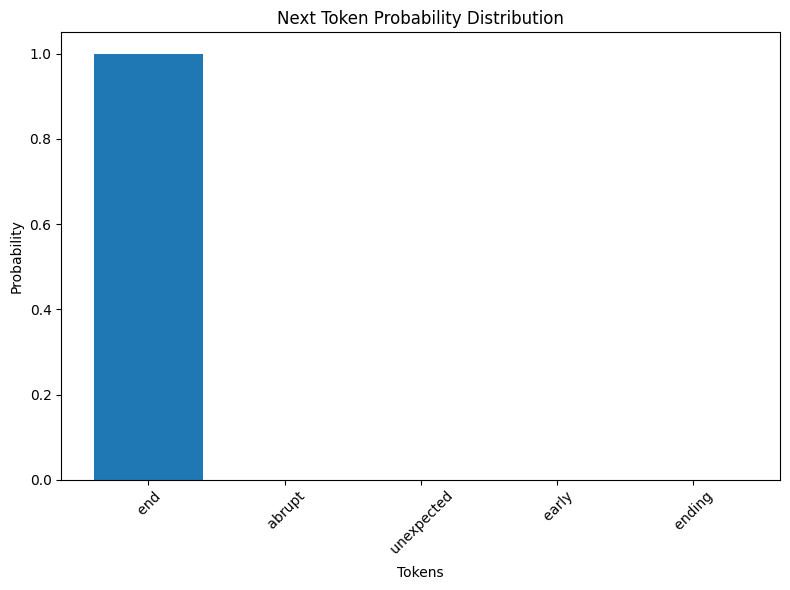


Top-5 predictions for next token:
'.': 0.9493
',': 0.0256
' last': 0.0135
'!': 0.0059
' and': 0.0035


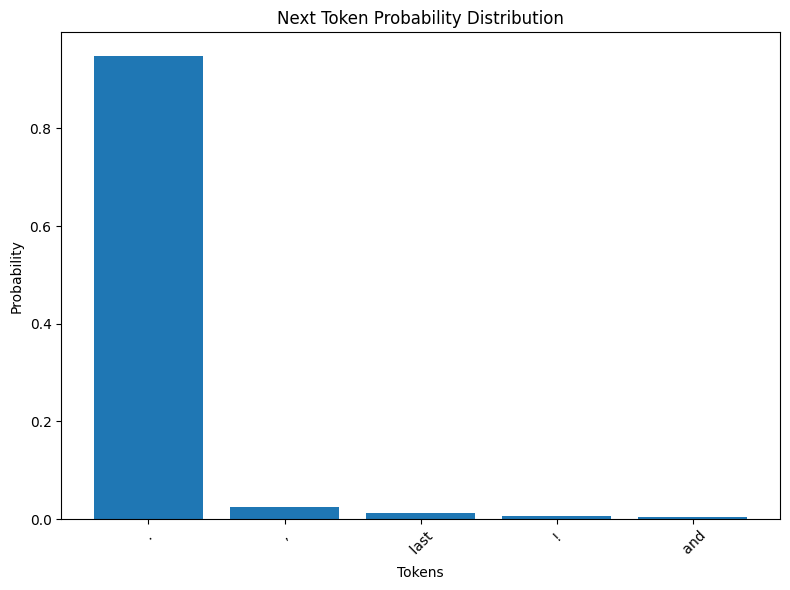


Top-5 predictions for next token:
' We': 0.8976
'
': 0.0776
' I': 0.0195
' It': 0.0034
' So': 0.0007


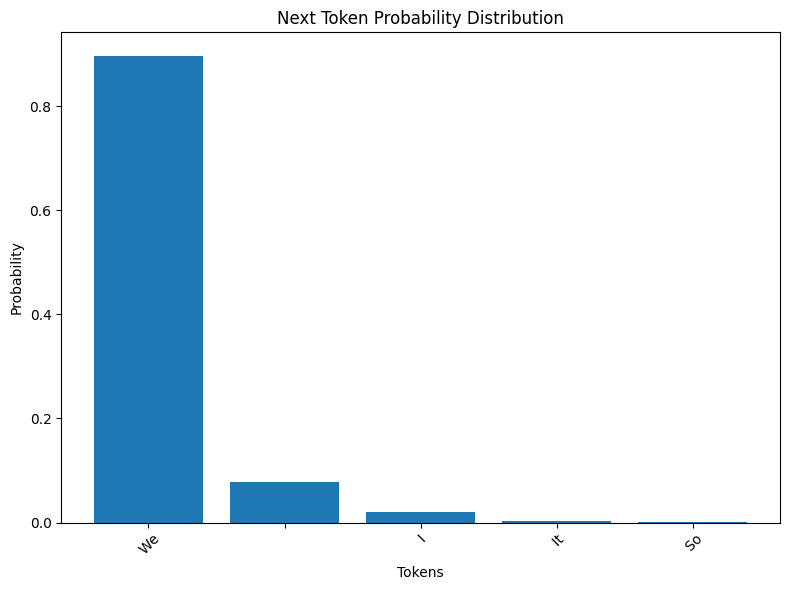


Top-5 predictions for next token:
''re': 0.9858
''ve': 0.0139
''ll': 0.0001
' have': 0.0001
' are': 0.0001


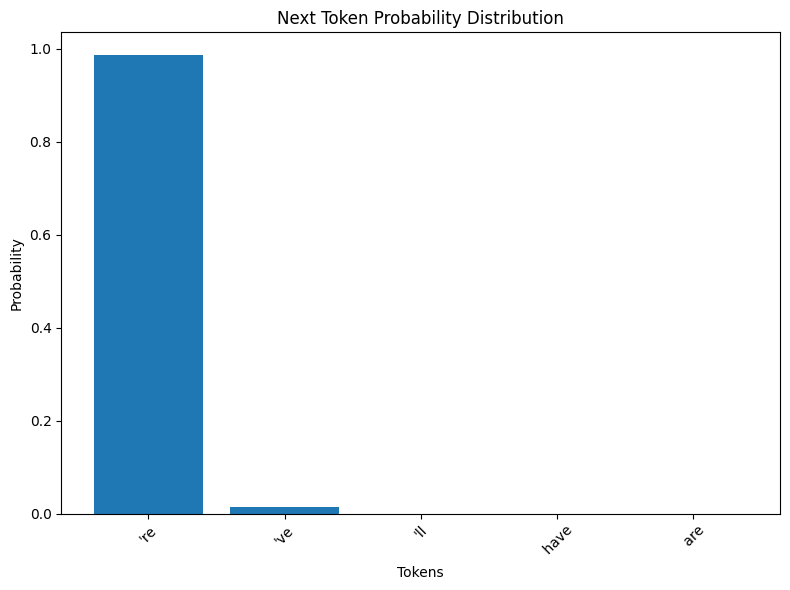


Top-5 predictions for next token:
' here': 0.7310
' going': 0.1770
' so': 0.0596
' celebrating': 0.0183
' all': 0.0040


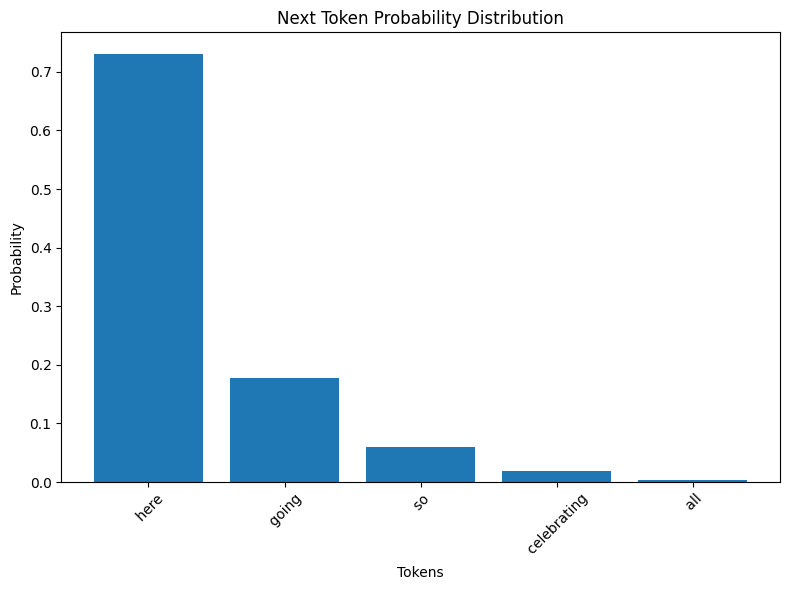


Top-5 predictions for next token:
' happy': 0.9492
' excited': 0.0499
' glad': 0.0007
' thankful': 0.0002
' proud': 0.0001


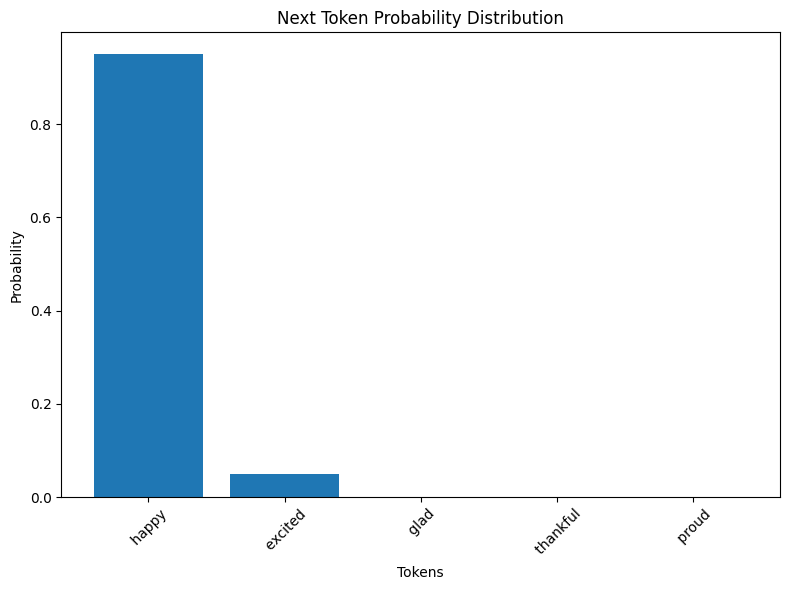


Top-5 predictions for next token:
' to': 0.9991
' that': 0.0008
' for': 0.0001
' we': 0.0000
' and': 0.0000


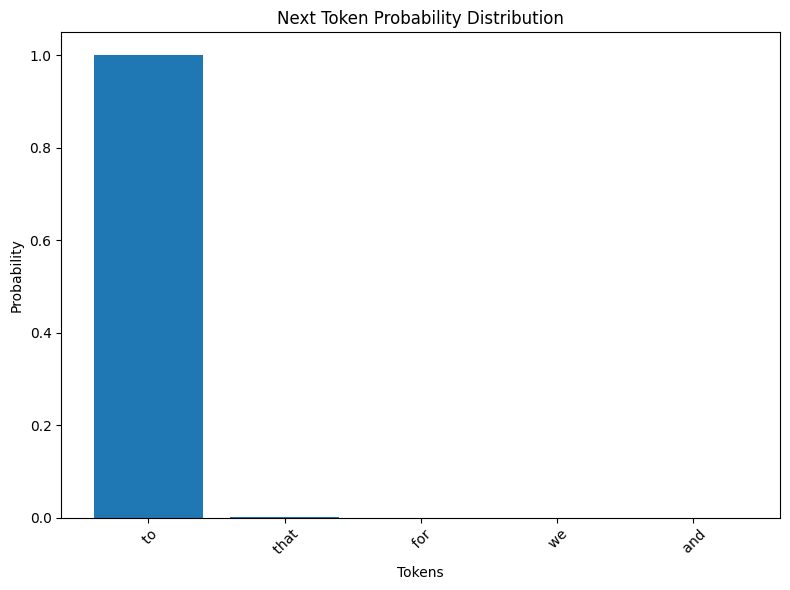


Top-5 predictions for next token:
' be': 0.9895
' have': 0.0085
' announce': 0.0019
' see': 0.0000
' welcome': 0.0000


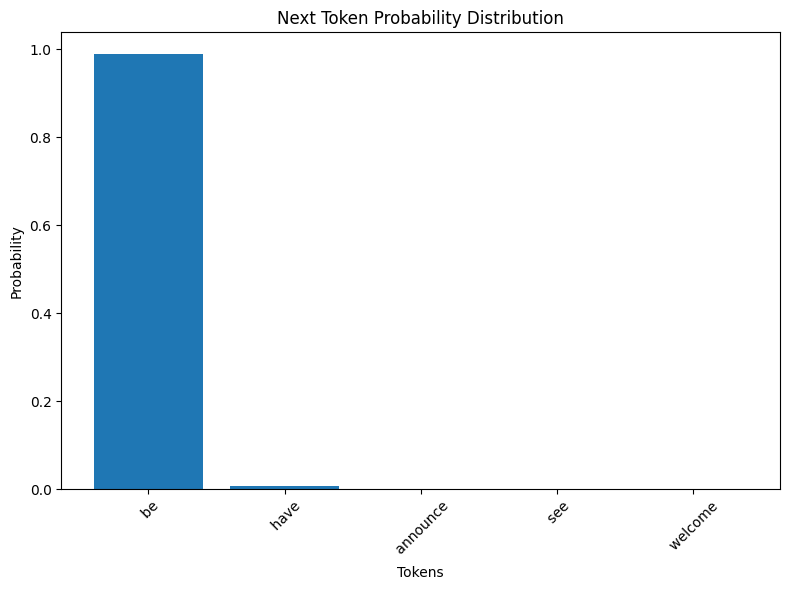


Top-5 predictions for next token:
' here': 0.9597
' back': 0.0400
' able': 0.0003
' home': 0.0000
' having': 0.0000


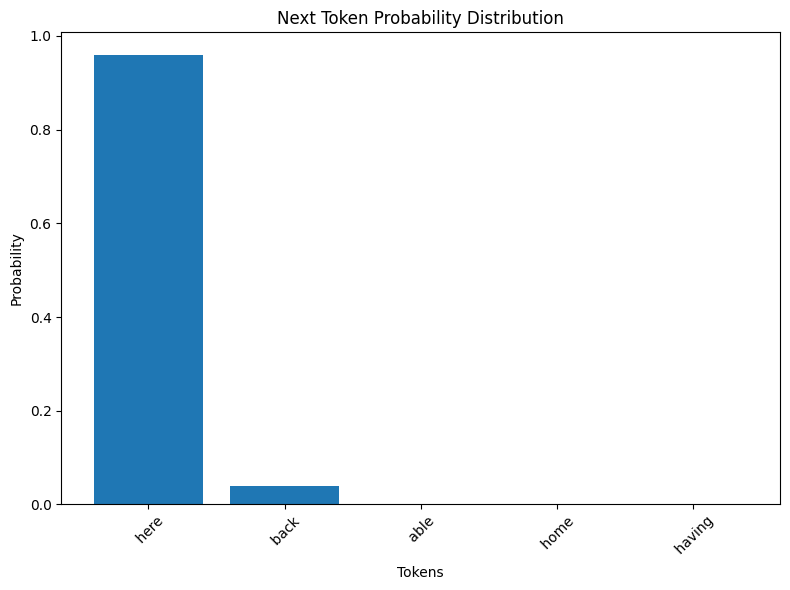


Top-5 predictions for next token:
'.': 0.5952
',': 0.1727
' and': 0.1319
' with': 0.0485
'!': 0.0438


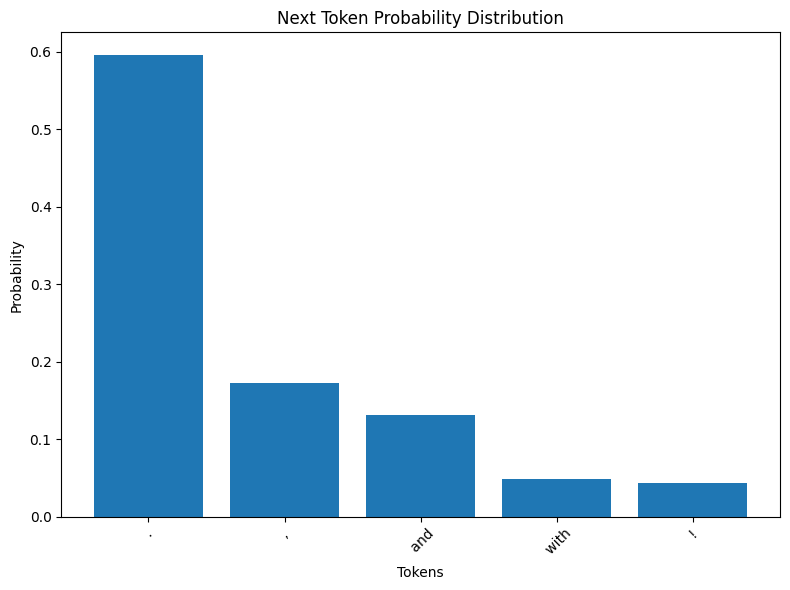


Generated text:
Hello! We're here celebrating new year after Christmas came to an end. We're so happy to be here. (...)


In [ ]:
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import numpy as np
import matplotlib.pyplot as plt

class ModelBuilder:
    def __init__(self):
        # Load pre-trained model & tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.model = GPT2LMHeadModel.from_pretrained('gpt2')
        self.model.eval()

    def generate_with_probabilities(self, prompt, temperature=0.5, top_k=5):
        """
        Generate next token predictions with their probabilities

        Args:
            prompt: Input text
            top_k: Number top/best predictions to return

        """

        self.top_k = top_k

        # Tokenize
        inputs = self.tokenizer.encode(prompt, return_tensors='pt')

        # Get predictions
        with torch.no_grad():
            outputs = self.model(inputs)
            logits = outputs.logits

        # Get probabilities for next token
        next_token_logits = logits[0, -1, :]

        # Use "temperature"
        if temperature != 0:
            next_token_logits = next_token_logits / temperature

        probs = F.softmax(next_token_logits, dim=-1)

        # Get top-k predictions
        top_k_probs, top_k_indices = torch.topk(probs, top_k)
        top_k_tokens = [self.tokenizer.decode([idx.item()]) for idx in top_k_indices]

        # Get next token
        next_token = torch.multinomial(probs, num_samples=1).unsqueeze(0)

        return next_token, top_k_tokens, top_k_probs.numpy()

    def visualize_probabilities(self, tokens, probs):
        """Create a bar chart of token probabilities"""
        plt.figure(figsize=(8, 6))
        plt.bar(tokens, probs)
        plt.title('Next Token Probability Distribution')
        plt.xlabel('Tokens')
        plt.ylabel('Probability')
        plt.xticks(rotation=45)
        plt.tight_layout()
        return plt

    def generate_text(self, prompt, max_length=50, temperature=1.0, show_probs=True):
        """
        Generate text from a prompt while showing the probability distribution

        Args:
            prompt (str): Starting text
            max_length (int): Maximum number of tokens to generate
            temperature (float): Controls randomness (higher = more random)
            show_probs (bool): Whether to print probability distributions
        """
        current_text = prompt

        for _ in range(max_length):
            # Get next token prediction and probabilities
            next_token, top_tokens, top_probs = self.generate_with_probabilities(current_text, temperature=temperature)

            # Show probability distribution
            if show_probs:
                print(f"\nTop-{self.top_k} predictions for next token:")
                for token, prob in zip(top_tokens, top_probs):
                    print(f"'{token}': {prob:.4f}")

                # Visualize probabilities
                self.visualize_probabilities(top_tokens, top_probs)
                plt.show()

            # Add predicted token to text
            current_text += self.tokenizer.decode(next_token[0])

            # Stop if we generate an end token
            if next_token.item() == self.tokenizer.eos_token_id:
                break

        return current_text

def get_text(prompt, temperature=0.5, max_length=10, show_probs=False):
    gpt2_model = ModelBuilder()

    print("Input prompt:", prompt)

    generated_text = gpt2_model.generate_text(
        prompt,
        max_length=max_length,
        temperature=temperature,
        show_probs=show_probs
    )

    print("\nGenerated text:")
    print(generated_text + " (...)")

get_text("Hello! We're here celebrating new year after Christmas came",
         max_length=12, temperature=0.2, show_probs=True)

In [ ]:
# Mayores valores de 1 entregan predicciones más aleatorias (lo que podría decirse "imaginativo")
# Valores menores entregan directamente predicciones más seguras - con mayor probabilidad (determinístico)
t_values = [0.05, 0.6, 1]
for t in t_values:
  print("T = ", t)
  get_text("Hello! We're here celebrating new year after Christmas",
         max_length=30, temperature=t)
  print("---"*5)

T =  0.05
Input prompt: Hello! We're here celebrating new year after Christmas

Generated text:
Hello! We're here celebrating new year after Christmas!


We're here to celebrate the new year with you!


We're here to celebrate the new year with you!


 (...)
---------------
T =  0.6
Input prompt: Hello! We're here celebrating new year after Christmas

Generated text:
Hello! We're here celebrating new year after Christmas, and I'm so excited to be able to share this special first part of our special event with you all!


A special thank you (...)
---------------
T =  1
Input prompt: Hello! We're here celebrating new year after Christmas

Generated text:
Hello! We're here celebrating new year after Christmas to help you celebrate in style with our Design e-Newsletter booth.


PRIVATE TEXT: We're delighted to confirm 26 new United (...)
---------------


Vemos que un valor de t muy bajo fue muy determinista, es decir, la red se fue por el lado seguro y decidió producir el mismo texto nuevamente, pues era lo más probable, y no había espacio para salirse de este rango.

Con un t intermedio, se inventa una historia casi normal.

Sin embargo, con un alto t = 1 se genera básicamente un cuento, incluyendo diálogos y una cita en algún lado.